# Random Error vs Accumulating Error — Animated

### What this notebook shows
We compare two different error processes for a measurement with true value \(x_0\):

1. **Independent random error**
$$
x_n = x_0 + \epsilon_n
$$

1. **Accumulating error**
$$
x_n = x_{n-1} + \epsilon_n
$$

In the first case, each measurement jumps around the true value.

In the second case, each error gets carried forward, so the measured value can **drift**.

### How to use it
- Adjust the sliders.
- Run the animation cell.
- Re-run to generate a new random experiment.
- Watch how the two processes behave differently.


In [2]:
%pip install ipywidgets  # needed by the in-browser (Pyodide) kernel
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import ipywidgets as widgets

## Controls

In [3]:
true_value = widgets.FloatSlider(
    value=10.0, min=0.0, max=20.0, step=0.5,
    description='True value'
)

error_size = widgets.FloatSlider(
    value=0.5, min=0.05, max=3.0, step=0.05,
    description='Error size'
)

n_measurements = widgets.IntSlider(
    value=40, min=10, max=120, step=5,
    description='Measurements'
)

frame_interval = widgets.IntSlider(
    value=120, min=30, max=500, step=10,
    description='Frame ms'
)

seed = widgets.IntSlider(
    value=1, min=1, max=9999, step=1,
    description='Seed'
)

show_running_mean = widgets.Checkbox(
    value=True,
    description='Show running mean'
)

controls = widgets.VBox([
    true_value,
    error_size,
    n_measurements,
    frame_interval,
    seed,
    show_running_mean
])

display(controls)

## Animated comparison

In [4]:
def make_animation(x0, sigma, n, interval, seed_value, show_mean=True):
    rng = np.random.default_rng(seed_value)

    # Model 1: independent random error
    independent = x0 + rng.normal(0, sigma, n)

    # Model 2: accumulating error / random walk
    steps = rng.normal(0, sigma, n)
    accumulating = x0 + np.cumsum(steps)

    t = np.arange(1, n + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
    ax1, ax2 = axes

    y_all = np.concatenate([independent, accumulating, [x0]])
    ypad = max(0.5, 0.15 * (y_all.max() - y_all.min() + 1e-9))
    ymin = y_all.min() - ypad
    ymax = y_all.max() + ypad

    for ax in axes:
        ax.set_xlim(1, n)
        ax.set_ylim(ymin, ymax)
        ax.axhline(x0, linestyle='--', linewidth=1.5, label='True value')
        ax.set_xlabel('Measurement number')
        ax.set_ylabel('Measured value')
        ax.grid(True, alpha=0.3)

    ax1.set_title('Independent random error')
    ax2.set_title('Accumulating error')

    line1, = ax1.plot([], [], marker='o', markersize=4, linewidth=1.5, label='Measurements')
    line2, = ax2.plot([], [], marker='o', markersize=4, linewidth=1.5, label='Measurements')

    mean1, = ax1.plot([], [], linestyle=':', linewidth=2, label='Running mean')
    mean2, = ax2.plot([], [], linestyle=':', linewidth=2, label='Running mean')

    text1 = ax1.text(0.02, 0.95, '', transform=ax1.transAxes, va='top')
    text2 = ax2.text(0.02, 0.95, '', transform=ax2.transAxes, va='top')

    ax1.legend(loc='lower right')
    ax2.legend(loc='lower right')

    plt.tight_layout()

    def init():
        line1.set_data([], [])
        line2.set_data([], [])
        mean1.set_data([], [])
        mean2.set_data([], [])
        text1.set_text('')
        text2.set_text('')
        return line1, line2, mean1, mean2, text1, text2

    def update(frame):
        k = frame + 1
        x = t[:k]

        y1 = independent[:k]
        y2 = accumulating[:k]

        line1.set_data(x, y1)
        line2.set_data(x, y2)

        if show_mean:
            rm1 = np.cumsum(y1) / np.arange(1, k + 1)
            rm2 = np.cumsum(y2) / np.arange(1, k + 1)
            mean1.set_data(x, rm1)
            mean2.set_data(x, rm2)
        else:
            mean1.set_data([], [])
            mean2.set_data([], [])

        text1.set_text(
            f'n = {k}\n'
            f'latest = {y1[-1]:.3f}\n'
            f'mean = {np.mean(y1):.3f}'
        )
        text2.set_text(
            f'n = {k}\n'
            f'latest = {y2[-1]:.3f}\n'
            f'mean = {np.mean(y2):.3f}'
        )

        return line1, line2, mean1, mean2, text1, text2

    anim = FuncAnimation(
        fig, update, frames=n, init_func=init,
        interval=interval, blit=False, repeat=False
    )

    plt.close(fig)
    return anim

anim = make_animation(
    x0=true_value.value,
    sigma=error_size.value,
    n=n_measurements.value,
    interval=frame_interval.value,
    seed_value=seed.value,
    show_mean=show_running_mean.value
)

HTML(anim.to_jshtml())

## What to notice

- In the **independent random error** case, the measurements fluctuate around the true value.
- In the **accumulating error** case, the measurements may **wander away** from the true value.
- The running mean usually settles well for independent random error.
- The drifting case can still look misleading even after many measurements.

### Quick question
Why does averaging help much more in the independent case than in the accumulating case?


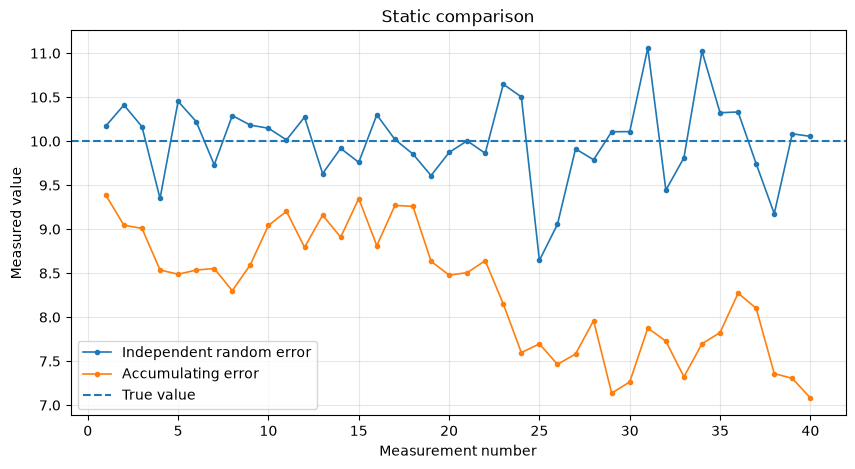

Independent: final mean = 10.0014, final std = 0.4709
Accumulating: final mean = 8.2978


In [5]:
# Optional: static summary plot for the current settings

rng = np.random.default_rng(seed.value)
x0 = true_value.value
sigma = error_size.value
n = n_measurements.value

independent = x0 + rng.normal(0, sigma, n)
accumulating = x0 + np.cumsum(rng.normal(0, sigma, n))
t = np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, independent, marker='o', markersize=3, linewidth=1.2, label='Independent random error')
ax.plot(t, accumulating, marker='o', markersize=3, linewidth=1.2, label='Accumulating error')
ax.axhline(x0, linestyle='--', linewidth=1.5, label='True value')
ax.set_xlabel('Measurement number')
ax.set_ylabel('Measured value')
ax.set_title('Static comparison')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

print(f'Independent: final mean = {np.mean(independent):.4f}, final std = {np.std(independent, ddof=1):.4f}')
print(f'Accumulating: final mean = {np.mean(accumulating):.4f}')